# Seminarski rad iz Istraživanja podataka 2

U ovom seminarskom radu korišćen je javno dostupan skup podataka koji sadrži fiziološka merenja prikupljena sa ciljem automatskog prepoznavanja vrste aktivnosti čoveka. Podaci su prikupljeni od **40 ispitanika** starosti između 20 i 49 godina (12 žena i 28 muškaraca), pri čemu je svaki ispitanik bio izložen četiri različite vrste aktivnosti: **1-neutralnoj (odmor), 2-mentalnoj, 3-emocionalnoj i 4-fizičkoj aktivnosti**. Eksperiment je trajao približno 90 minuta po ispitaniku.

Tokom eksperimenta mereni su fiziološki signali **elektrokardiograma (ECG)**, **torakalne električne bioimpedanse (TEB)** i **elektrodermalne aktivnosti (EDA)** pomoću nosivih senzora. Na osnovu ovih signala izračunat je veliki broj karakteristika (feature-a) u vremenskom i frekvencijskom domenu, uključujući različite statističke pokazatelje, parametre varijabilnosti srčanog ritma, energetske karakteristike, kao i druge srodne osobine. Na taj način dobijeno je ukupno **533 prediktora**.

## Preprocesiranje
Na samom početku, učitaćemo podatke iz .csv fajla gde se nalaze podaci o potrebnim prediktorima, a prediktore (labels) ćemo učitati preko funkcije .strip.


In [2]:
import pandas as pd

data = pd.read_csv("C:\\Users\\gala.posedi\\Downloads\\sensors-19-05524-s001\\sensors-19-05524-s001_new\\data.txt", header= None)
#u .txt fajlu labels poslednji red nam objasnjava kako se cita prediktor Activity, pa ga csv fajl ne moze prepoznati
#koristicemo funkciju .strip koji uklanja \n, tj novi red i druge razmake
#labels nije napisan u formatu standardne tabele, vec u formatu obicnog teksualnog fajla

#otvaramo fajl preko list comprehension
with open(r"C:\\Users\\gala.posedi\\Downloads\\sensors-19-05524-s001\\sensors-19-05524-s001_new\\labels.txt", "r") as f:
    labels = [line.strip() for line in f if line.strip()]

#preimenovacemo poslednju kolonu u Activity, bez objasnjenja kolone
labels[-1] = "Activity"
#data.columns = labels

Kako su autori zadržali ista imena kolona za različite stvari koje mere (negde je vršen EDA za ruke, negde za podlaktice ali nigde nije naglašeno koji je koji), moraćemo promeniti naziv duplikatima, da bismo kasnije mogli vršiti dalju analizu.

In [3]:
from collections import defaultdict

counts = defaultdict(int)
labels_unique = []

for label in labels:
    counts[label] += 1
    
    if counts[label] == 1:
        labels_unique.append(label)
    else:
        labels_unique.append(label + "_" + str(counts[label]))

data.columns = labels_unique

print("Broj kolona:", data.shape[1])
print("Broj dupliranih naziva:", data.columns.duplicated().sum())

Broj kolona: 535
Broj dupliranih naziva: 0


In [4]:
print(data.columns)

Index(['Subject index (1-40)', 'ECG_original_mean', 'ECG_original_std',
       'ECG_original_trimmean25', 'ECG_original_median',
       'ECG_original_skewness', 'ECG_original_kurtosis', 'ECG_original_max',
       'ECG_original_min', 'ECG_original_prctile25',
       ...
       'EDA_Functionals_power_Filt2kurtosis_2',
       'EDA_Functionals_power_Filt2max_2', 'EDA_Functionals_power_Filt2min_2',
       'EDA_Functionals_power_Filt2prctile25_2',
       'EDA_Functionals_power_Filt2prctile75_2',
       'EDA_Functionals_power_Filt2geomean(abs)_2',
       'EDA_Functionals_power_Filt2harmmean_2',
       'EDA_Functionals_power_Filt2mad_2',
       'EDA_Functionals_power_Filt2baseline_2', 'Activity'],
      dtype='object', length=535)


Proveravamo dimenzije naše baze podataka, kao i broj redova koji pripadaju svakoj vrednosti target-a Activity, a kasnije ćemo pogledati tipovi svih atributa, kao i opšte informacije o bazi.

In [5]:
print("Dimenzije baze podataka: ", data.shape)
print("Broj redova za svaku vrednost target-a:")
print(data['Activity'].value_counts())

Dimenzije baze podataka:  (4480, 535)
Broj redova za svaku vrednost target-a:
Activity
1    1120
3    1120
2    1120
4    1120
Name: count, dtype: int64


In [6]:
print("Tipovi atributa:", data.dtypes)
print("\n")
print("Opšte informacije o bazi:")
print(data.info())

Tipovi atributa: Subject index (1-40)                           int64
ECG_original_mean                            float64
ECG_original_std                             float64
ECG_original_trimmean25                      float64
ECG_original_median                          float64
                                              ...   
EDA_Functionals_power_Filt2geomean(abs)_2    float64
EDA_Functionals_power_Filt2harmmean_2        float64
EDA_Functionals_power_Filt2mad_2             float64
EDA_Functionals_power_Filt2baseline_2        float64
Activity                                       int64
Length: 535, dtype: object


Opšte informacije o bazi:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4480 entries, 0 to 4479
Columns: 535 entries, Subject index (1-40) to Activity
dtypes: float64(520), int64(15)
memory usage: 18.3 MB
None


Analizom tipova podataka ustanovljeno je da su svi atributi numeričkog tipa (int64 ili float64). Ciljna promenljiva Activity već je predstavljena numerički, a kolonu "Subject Index" ćemo izbaciti iz baze, jer ne pruža dodatne informacije o prediktorima i bazi, a može uticati na performanse algoritama klasifikacije i klasterizacije.
.
Proveravamo i da li postoje nedostajuće vrednosti, kao i duplikati, i ukoliko ih ima, uklanjamo ih iz baze.

In [7]:
data.drop(columns = ["Subject index (1-40)"], inplace = True)
print("Broj nedostajućih vrednosti po kolonama:")
print(data.isna().sum())
print("Broj duplikata:")
print(data.duplicated().sum())
print("Broj duplikata po kolonama:")
print(data.columns.duplicated().sum())

Broj nedostajućih vrednosti po kolonama:
ECG_original_mean                            0
ECG_original_std                             0
ECG_original_trimmean25                      0
ECG_original_median                          0
ECG_original_skewness                        0
                                            ..
EDA_Functionals_power_Filt2geomean(abs)_2    0
EDA_Functionals_power_Filt2harmmean_2        0
EDA_Functionals_power_Filt2mad_2             0
EDA_Functionals_power_Filt2baseline_2        0
Activity                                     0
Length: 534, dtype: int64
Broj duplikata:
0
Broj duplikata po kolonama:
0


### Redukcija početnog skupa podataka
S obzirom na to da skup podataka sadrži veliki broj prediktora dobijenih iz istih fizioloških signala, očekuje se postojanje značajne međusobne korelacije između njih. Zbog toga ćemo izvršiti određenu redukciju baze, najpre primenom Pirsonovog koeficijenta korelacije, a kasnije i pomoću redukcije dimnezionalnosti, koristeći PCA metodu.

In [8]:
import numpy as np

X = data.drop(columns=["Activity"])
y = data["Activity"]

corr_matrix = X.corr().abs()

upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [column for column in upper_triangle.columns if any(upper_triangle[column] > 0.8)]

X_pearson = X.drop(columns=to_drop)

pearson_data = X_pearson.copy()
pearson_data["Activity"] = y

print("Broj atributa pre Pirsonove redukcije:", X.shape[1])
print("Broj izbačenih atributa:", len(to_drop))
print("Broj atributa posle Pirsonove redukcije:", X_pearson.shape[1])

Broj atributa pre Pirsonove redukcije: 533
Broj izbačenih atributa: 430
Broj atributa posle Pirsonove redukcije: 103


PCA metod za redukovanje dimenzionalnosti i implementacija t-SNE metode za 2D vizuelizaciju podataka: 

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_standardized = scaler.fit_transform(X)

In [10]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_standardized)
print("Broj komponenti posle PCA:", pca.n_components_)
print("Udeo svake komponente:", pca.explained_variance_ratio_)
print("Procenat disperzije objašnjen sa PCA:", pca.explained_variance_ratio_.sum())

Broj komponenti posle PCA: 61
Udeo svake komponente: [0.18457093 0.11944473 0.11201854 0.10262701 0.05041005 0.04335714
 0.02562293 0.02340832 0.02257984 0.01894359 0.01686517 0.01384434
 0.01336002 0.01265527 0.01213856 0.01065933 0.01049484 0.00941335
 0.00877775 0.00816402 0.00758126 0.00622047 0.00613049 0.00604647
 0.00559769 0.00545748 0.00484377 0.00454554 0.0044642  0.00434581
 0.00425419 0.00389667 0.00373631 0.0036342  0.00341261 0.00332661
 0.0031459  0.00300596 0.00279069 0.00257052 0.0025343  0.00249466
 0.00240817 0.00230266 0.00230096 0.00218483 0.00215148 0.0021329
 0.00202237 0.0019856  0.00194357 0.00193    0.00189689 0.00187195
 0.00184624 0.00182563 0.00180758 0.00179829 0.00175173 0.0017036
 0.00166371]
Procenat disperzije objašnjen sa PCA: 0.9509196965411426


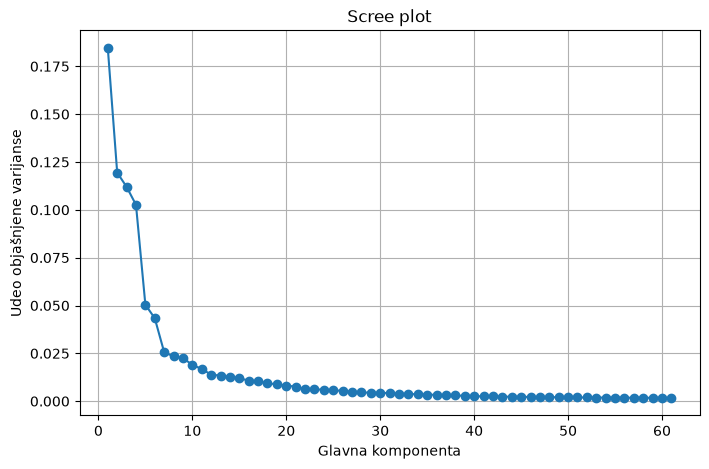

In [11]:
from matplotlib import pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, marker='o')

plt.xlabel("Glavna komponenta")
plt.ylabel("Udeo objašnjene varijanse")
plt.title("Scree plot")
plt.grid(True)

plt.show()

Možemo i vizuelno pokazati da nam je 61 prediktor sasvim dovoljan, jer objašnjavaju dovoljni udeo disperzije.

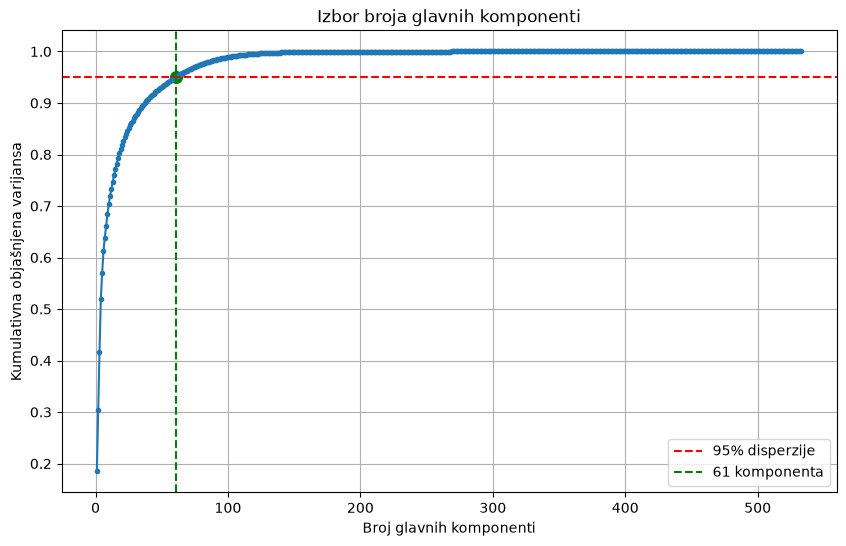

In [12]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

pca_all = PCA()
pca_all.fit(X_standardized)

#kumulativna disperzija
cum_var = np.cumsum(pca_all.explained_variance_ratio_)

n95 = np.argmax(cum_var >= 0.95) + 1

plt.figure(figsize=(10,6))
plt.plot(range(1, len(cum_var)+1), cum_var, marker='o', markersize=3)
plt.axhline(y=0.95, color='red', linestyle='--', label='95% disperzije')
plt.axvline(x=n95, color='green', linestyle='--',label=f'{n95} komponenta')

plt.scatter(n95, cum_var[n95-1], color='green', s=70)

plt.xlabel("Broj glavnih komponenti")
plt.ylabel("Kumulativna objašnjena varijansa")
plt.title("Izbor broja glavnih komponenti")
plt.grid(True)
plt.legend()

plt.show()



Prikazaćemo prvih 10 PCA komponenti, i videti od čega su sačinjene, kao i koji atribut ima najveći uticaj na svaku komponentu.

In [13]:
loadings = pd.DataFrame(pca.components_.T,columns=[f"PC{i+1}" for i in range(pca.n_components_)],index=X.columns)

for pc in ["PC1", "PC2", "PC3", "PC4", "PC5", "PC6", "PC7", "PC8", "PC9", "PC10"]:
    print(loadings.loc[loadings[pc].abs().sort_values(ascending=False).index, [pc]].head(4))

                   PC1
ECG_hrv_std   0.085959
ECG_PSD_mad   0.085544
ECG_hrv_mad   0.085501
ECG_PSD_mean  0.085484
                              PC2
IT_LF_max_2              0.090693
IT_LF_prctile75_2        0.090693
IT_p_Total_harmmean      0.090639
IT_p_Total_geomean(abs)  0.090635
                        PC3
IT_PSD_std         0.083672
IT_LF_prctile25_2  0.083333
IT_LF_min_2        0.083333
IT_LF_harmmean_2   0.083323
                                              PC4
EDA_Functionals_power_Fil12geomean(abs)  0.100793
EDA_Functionals_power_Fil12prctile25     0.100489
EDA_Functionals_power_Fil12trimmean25    0.100103
EDA_Functionals_power_Fil12prctile75     0.099999
                       PC5
IT_LF_Area        0.151097
IT_LF_mean        0.151097
IT_Original_Area  0.151078
IT_Original_mean  0.151078
                                  PC6
ECG_HR_min_div_harmmean      0.114083
ECG_HR_min_div_prctile25     0.113922
ECG_hrv_prctile25            0.110237
ECG_HR_min_div_geomean(abs)  0.110161


Na osnovu loading-a može se zaključiti da je prva glavna komponenta (PC1), koja objašnjava najveći udeo disperzije u prostoru prediktora, gotovo isključivo određena EKG karakteristikama, i to sa skoro identičnim koeficijentima, što ukazuje da su te ECG karakteristike međusobno jako korelisane i predstavljaju dominantan izvor varijabilnosti unutar celog skupa prediktora. Slično, PC2, PC3 i PC5 su određene karakteristikama torakalne bioimpedanse, dok je PC4 određena EDA karakteristikama.

PCA je nenadgledana metoda i nema informaciju o ciljnoj promenljivoj Activity, pa se iz prethodnog ne može direktno zaključiti koji signal najbolje razlikuje tipove aktivnosti. Da bismo proverili koji signali zaista najviše doprinose razlikovanju aktivnosti, uporedićemo ovaj nalaz  sa XGBoost feature importance grafikom nad originalnim atributima nešto kasnije.

### Vizuelizacija prethodnih metoda redukcija dimenzionalnosti korišćenjem t-SNE metode


In [14]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

scaler_pearson = StandardScaler()
X_pearson_standardized = scaler_pearson.fit_transform(X_pearson)

tsne_pearson = TSNE(n_components=2, perplexity=30, learning_rate="auto", init="pca", random_state=42)

X_tsne_pearson = tsne_pearson.fit_transform(X_pearson_standardized)

In [15]:
tsne_pca = TSNE(n_components=2, perplexity=30, learning_rate="auto", init="pca", random_state=42)
X_tsne_pca = tsne_pca.fit_transform(X_pca)

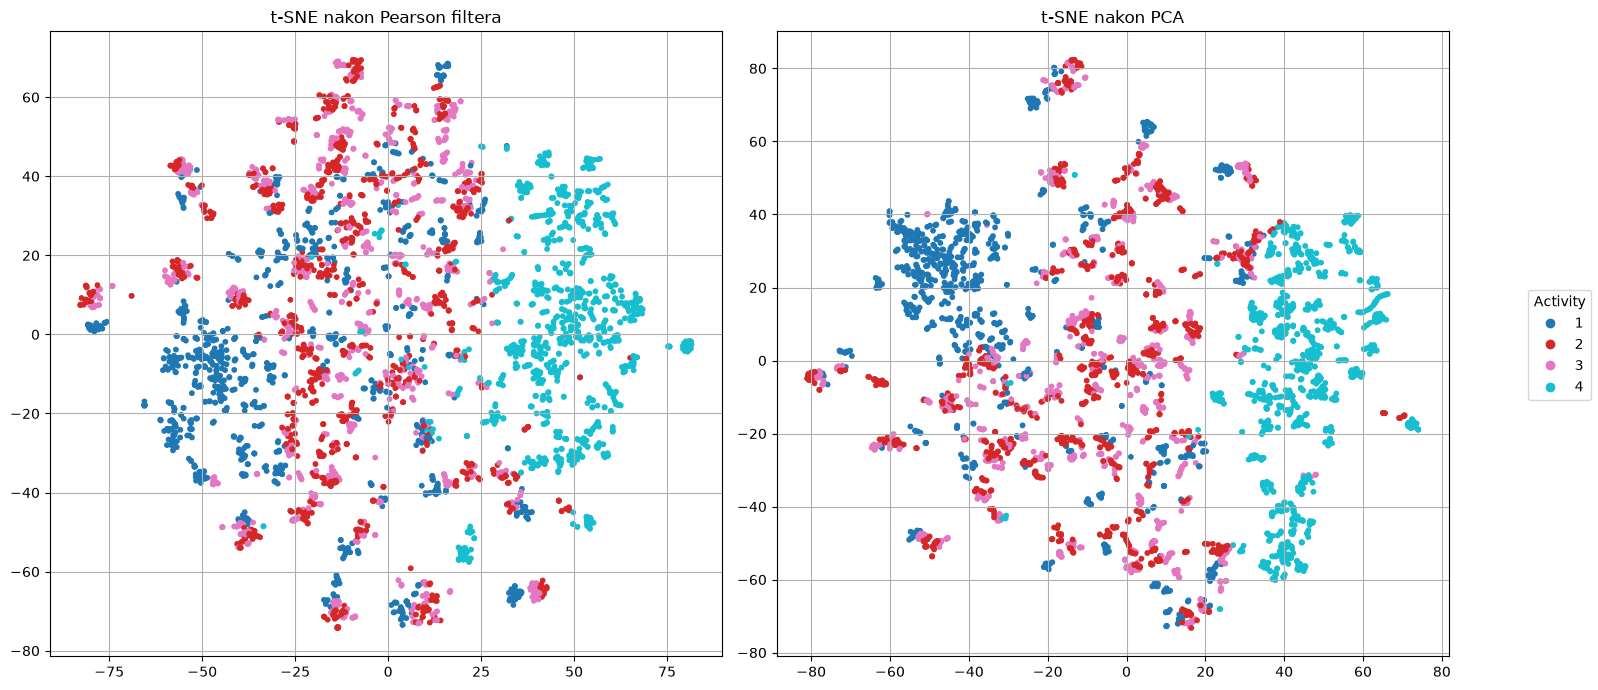

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

scatter1 = axes[0].scatter(X_tsne_pearson[:, 0], X_tsne_pearson[:, 1], c = y, cmap="tab10", s=10)

axes[0].set_title("t-SNE nakon Pearson filtera")
axes[0].grid(True)

scatter2 = axes[1].scatter(X_tsne_pca[:, 0], X_tsne_pca[:, 1], c = y, cmap="tab10", s=10)

axes[1].set_title("t-SNE nakon PCA")
axes[1].grid(True)

fig.legend(handles=scatter1.legend_elements()[0], labels = range(1,5),title="Activity",loc="center right")
plt.tight_layout(rect=[0, 0, 0.92, 1])
plt.show()

Na osnovu dobijenih grafika može se uočiti da obe metode omogućavaju izdvajanje četvrte klase (fizička aktivnost), dok se druga i treća klasa (mentalna i emocionalna aktivnost) značajno preklapaju. Ovo je fiziološki očekivano - mentalni i emocionalni stres izazivaju slične promene u EKG i EDA signalima (povišen otkucaj srca, promene provodljivosti kože), dok fizička aktivnost ima jasno drugačijie fiziološke simptome, pa se lakše izdvaja u prostoru.

Projekcija nakon PCA pokazuje nešto kompaktnije klastere, posebno za prvu klasu, što ukazuje da PCA uspešnije zadržava globalnu strukturu podataka nakon redukcije dimenzionalnosti u odnosu na Pirsonov filter. Ovo je razumljivo jer PCA komponente predstavljaju linearne kombinacije svih originalnih atributa birane tako da maksimizuju objašnjenu varijansu, dok Pirsonov filter samo uklanja redundantne atribute, ali ne kombinuje preostale informacije na optimalan način.

## Klasifikacija

Za klasifikaciju target-a odabrano je pet algoritama različite složenosti i principa rada. Prva je logistička regresija, pa SVM kao metoda pogodna za nelinearne granice odlučivanja, pa Random Forest kao predstavnik bagging ensemble metoda i na kraju su implementirane AdaBoost i XGBoost koje predstavljaju dve boosting metode.

Svaki model treniramo i evaluiramo nad dva skupa prediktora - nad svim originalnim standardizovanim atributima (533 prediktora) i nad skupom dobijenim PCA redukcijom (61 komponenta koja objašnjava 95% varijanse). Na taj način ćemo za svaki algoritam moći da procenimo koliko redukcija dimenzionalnosti utiče na performanse.

Kako su sve četiri klase target promenljive Activity podjednako zastupljene (po 1120 uzoraka), za evaluaciju koristimo accuracy kao osnovnu meru, ali i precision, recall i F1-score računate sa "weighted" usrednjavanjem, čime obezbeđujemo da nijedna klasa ne bude zanemarena prilikom ocene modela. Radi lakšeg poređenja svih modela na kraju ove sekcije, rezultate svakog modela čuvaćemo u zajedničkoj listi `results_clf`.

In [17]:
results_clf = []

### Logistička regresija
Kako postoje četiri vrste klase target promenljive Activity, koristićemo polinomijalnu logističku regresiju.

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score)

X_train_all, X_test_all, y_train, y_test = train_test_split(
    X_standardized,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print(X_train_all.shape, X_test_all.shape)
print(y_train.shape, y_test.shape)

(3136, 533) (1344, 533)
(3136,) (1344,)


In [19]:
model = LogisticRegression(solver="lbfgs", max_iter = 1000, random_state = 42)
model.fit(X_train_all, y_train)

y_pred = model.predict(X_test_all)

matrica_konfuzije_all = confusion_matrix(y_test, y_pred)


In [20]:
#metrike evaluacije

accuracy_all = accuracy_score(y_test, y_pred)
precision_all = precision_score(y_test, y_pred, average="weighted")
recall_all = recall_score(y_test, y_pred, average="weighted")
f1_all = f1_score(y_test, y_pred, average="weighted")

print(f"Accuracy : {accuracy_all:.4f}")
print(f"Precision: {precision_all:.4f}")
print(f"Recall   : {recall_all:.4f}")
print(f"F1-score : {f1_all:.4f}")

results_clf.append({
    "Model": "Logisticka regresija",
    "Skup prediktora": "Svi atributi",
    "Accuracy": accuracy_all,
    "Precision": precision_all,
    "Recall": recall_all,
    "F1-score": f1_all
})

Accuracy : 0.8728
Precision: 0.8729
Recall   : 0.8728
F1-score : 0.8728


Sada ćemo implementirati logističku regresiju nad određenim skupom podataka koji smo dobili PCA redukcijom.

In [21]:
X_train_pca, X_test_pca, y_train, y_test = train_test_split(
    X_pca, y,
    test_size=0.3,      
    train_size=0.7,     
    random_state=42,    
    stratify=y         
)

model = LogisticRegression(solver="lbfgs", max_iter = 1000, random_state = 42)
model.fit(X_train_pca, y_train)

y_pred = model.predict(X_test_pca)

matrica_konfuzije_pca = confusion_matrix(y_test, y_pred)

In [22]:
#metrike evaluacije

accuracy_pca = accuracy_score(y_test, y_pred)
precision_pca = precision_score(y_test, y_pred, average="weighted")
recall_pca = recall_score(y_test, y_pred, average="weighted")
f1_pca = f1_score(y_test, y_pred, average="weighted")

print(f"Accuracy : {accuracy_pca:.4f}")
print(f"Precision: {precision_pca:.4f}")
print(f"Recall   : {recall_pca:.4f}")
print(f"F1-score : {f1_pca:.4f}")

results_clf.append({
    "Model": "Logisticka regresija",
    "Skup prediktora": "Posle PCA",
    "Accuracy": accuracy_pca,
    "Precision": precision_pca,
    "Recall": recall_pca,
    "F1-score": f1_pca
})

Accuracy : 0.8132
Precision: 0.8154
Recall   : 0.8132
F1-score : 0.8142


Sada ćemo uporediti matrice konfuzije ovih dvaju skupa prediktora.

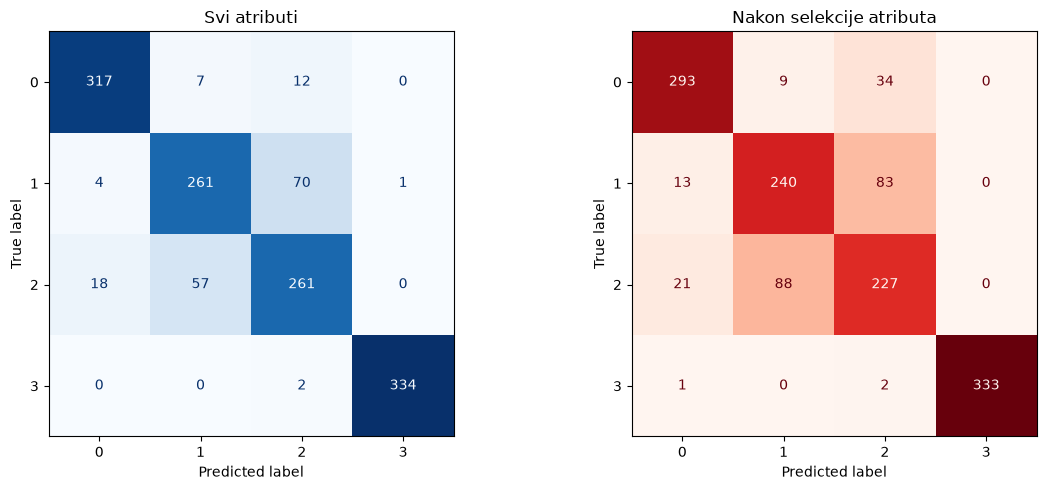

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(confusion_matrix=matrica_konfuzije_all).plot(ax=axes[0],cmap="Blues", values_format="d", colorbar=False)
axes[0].set_title("Svi atributi") 

ConfusionMatrixDisplay(confusion_matrix=matrica_konfuzije_pca).plot(ax=axes[1],cmap="Reds",values_format="d",colorbar=False)
axes[1].set_title("Nakon selekcije atributa")

plt.tight_layout()
plt.show()

Nakon redukcije broja prediktora tačnost opada sa 0.87 na 0.81, a slično se ponašaju i precision, recall i F1-score. Na matrici konfuzije se vidi da se broj pogrešno klasifikovanih uzoraka povećava naročito između klasa 2 (mentalna) i 3 (emocionalna aktivnost) - što je u skladu i sa t-SNE vizuelizacijom iz prethodne sekcije, gde su se baš te dve klase najviše preklapale.

Ovo ukazuje da su pojedini atributi odbačeni PCA transformacijom sadržali diskriminativne informacije važne baš za razlikovanje ove dve klase. Iako selekcija atributa doprinosi smanjenju dimenzionalnosti i može povećati jednostavnost i brzinu treniranja modela, u ovom slučaju je dovela do primetnog gubitka informacija relevantnih za klasifikaciju, jer preostalih 5% varijanse očigledno nije bilo šum, već je sadržalo diskriminativan signal.

Ovakav rezultat je delimično u skladu sa prethodnom analizom podataka, koja je pokazala da su mnogi prediktori međusobno visoko korelisani (Pearson filter je odbacio čak 430 od 533 atributa zbog korelacije preko 0.8). Kod linearnog modela kao što je logistička regresija, redundantni, visoko korelisani atributi generalno ne unose mnogo nove informacije, pa bi njihovo uklanjanje trebalo da ima blag uticaj na performanse modela.


### SVM model
Sada ćemo klasifikovati target promenljivu koristeći SVM metod, da bismo videli da li nelinearni metod bolje predviđa target promenljivu od linearnog.

In [24]:
from sklearn.svm import SVC

svm_model_all = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)

svm_model_all.fit(X_train_all, y_train)
y_pred_svm_all = svm_model_all.predict(X_test_all)

matrica_konfuzije_svm_all = confusion_matrix(y_test, y_pred_svm_all)

In [25]:
accuracy_all = accuracy_score(y_test, y_pred_svm_all)
precision_all = precision_score(y_test, y_pred_svm_all, average="weighted")
recall_all = recall_score(y_test, y_pred_svm_all, average="weighted")
f1_all = f1_score(y_test, y_pred_svm_all, average="weighted")

print(f"Accuracy : {accuracy_all:.4f}")
print(f"Precision: {precision_all:.4f}")
print(f"Recall   : {recall_all:.4f}")
print(f"F1-score : {f1_all:.4f}")

results_clf.append({
    "Model": "SVM",
    "Skup prediktora": "Svi atributi",
    "Accuracy": accuracy_all,
    "Precision": precision_all,
    "Recall": recall_all,
    "F1-score": f1_all
})

Accuracy : 0.8430
Precision: 0.8471
Recall   : 0.8430
F1-score : 0.8437


Sada ćemo implementirati model nad PCA atributima.

In [26]:
svm_model_pca = SVC(kernel="rbf",C=1.0,gamma="scale",random_state=42)

svm_model_pca.fit(X_train_pca, y_train)
y_pred_svm_pca = svm_model_pca.predict(X_test_pca)

matrica_konfuzije_svm_pca = confusion_matrix(y_test, y_pred_svm_pca)

In [27]:
#metrike evaluacije

accuracy_pca = accuracy_score(y_test, y_pred_svm_pca)
precision_pca = precision_score(y_test, y_pred_svm_pca, average="weighted")
recall_pca = recall_score(y_test, y_pred_svm_pca, average="weighted")
f1_pca = f1_score(y_test, y_pred_svm_pca, average="weighted")

print(f"Accuracy : {accuracy_pca:.4f}")
print(f"Precision: {precision_pca:.4f}")
print(f"Recall   : {recall_pca:.4f}")
print(f"F1-score : {f1_pca:.4f}")

results_clf.append({
    "Model": "SVM",
    "Skup prediktora": "Posle PCA",
    "Accuracy": accuracy_pca,
    "Precision": precision_pca,
    "Recall": recall_pca,
    "F1-score": f1_pca
})

Accuracy : 0.8311
Precision: 0.8372
Recall   : 0.8311
F1-score : 0.8325




Matrice konfuzije za oba skupa podataka:

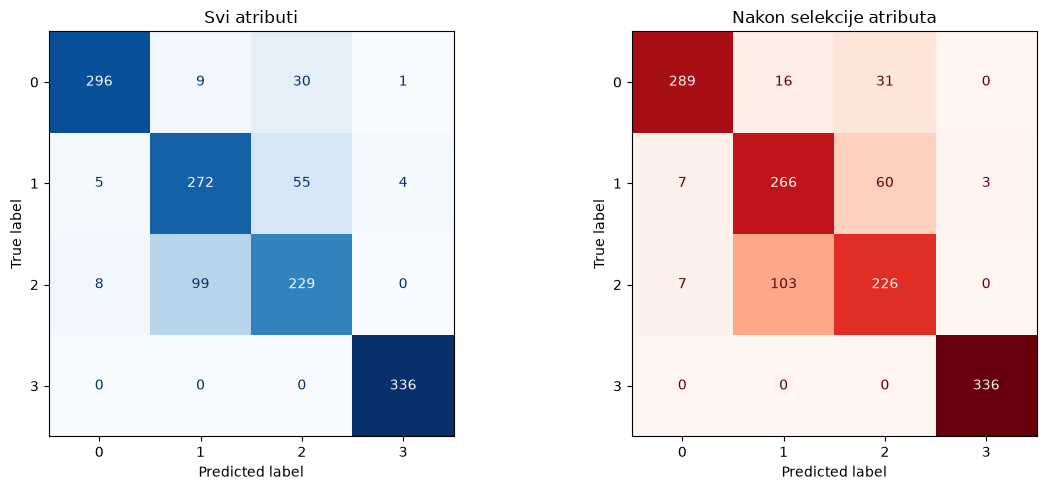

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(confusion_matrix=matrica_konfuzije_svm_all).plot(ax=axes[0],cmap="Blues", values_format="d", colorbar=False)
axes[0].set_title("Svi atributi") 

ConfusionMatrixDisplay(confusion_matrix=matrica_konfuzije_svm_pca).plot(ax=axes[1],cmap="Reds",values_format="d",colorbar=False)
axes[1].set_title("Nakon selekcije atributa")

plt.tight_layout()
plt.show()

SVM sa Gausovim jezgrom nad PCA skupom postiže Accuracy oko 0.83, što je bolje od logističke regresije nad istim skupom (0.81), a ukazuje da granice između klasa 2 i 3 (mentalna i emocionalna aktivnost) nisu čisto linearne - nelinearno jezgro uspeva da povrati deo performansi izgubljen redukcijom dimenzionalnosti. Ovo je očekivano jer fiziološki signali (ECG, EDA, TEB) često imaju nelinearne zavisnosti sa tipom aktivnosti, pa je razumno da model koji dozvoljava nelinearne granice bolje generalizuje nad redukovanim, informativno "sažetim" prostorom PCA komponenti u odnosu na model koji pretpostavlja linearnu razdvojivost klasa.

### Random forest model
Random Forest je ansambl algoritam koji klasifikaciju vrši kombinovanjem rezultata velikog broja stabala odlučivanja. Ovakav pristup povećava tačnost modela i smanjuje rizik od preprilagođavanja.

In [29]:
from sklearn.ensemble import RandomForestClassifier

rf_model_all = RandomForestClassifier(
    n_estimators=100,
    criterion="gini",
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model_all.fit(X_train_all, y_train)

y_pred_all = rf_model_all.predict(X_test_all)

accuracy_all = accuracy_score(y_test, y_pred_all)
precision_all = precision_score(y_test, y_pred_all, average='weighted')
recall_all = recall_score(y_test, y_pred_all, average='weighted')
f1_all = f1_score(y_test, y_pred_all, average='weighted')

print(f"Accuracy : {accuracy_all:.4f}")
print(f"Precision: {precision_all:.4f}")
print(f"Recall   : {recall_all:.4f}")
print(f"F1-score : {f1_all:.4f}")

matrica_konfuzije_rf_all = confusion_matrix(y_test, y_pred_all)

results_clf.append({
    "Model": "Random Forest",
    "Skup prediktora": "Svi atributi",
    "Accuracy": accuracy_all,
    "Precision": precision_all,
    "Recall": recall_all,
    "F1-score": f1_all
})

Accuracy : 0.9583
Precision: 0.9593
Recall   : 0.9583
F1-score : 0.9585


In [30]:
rf_model_pca = RandomForestClassifier(
    n_estimators=100,
    criterion="gini",
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model_pca.fit(X_train_pca, y_train)

y_pred_pca = rf_model_pca.predict(X_test_pca)

accuracy_pca = accuracy_score(y_test, y_pred_pca)
precision_pca = precision_score(y_test, y_pred_pca, average='weighted')
recall_pca = recall_score(y_test, y_pred_pca, average='weighted')
f1_pca = f1_score(y_test, y_pred_pca, average='weighted')

print(f"Accuracy : {accuracy_pca:.4f}")
print(f"Precision: {precision_pca:.4f}")
print(f"Recall   : {recall_pca:.4f}")
print(f"F1-score : {f1_pca:.4f}")

matrica_konfuzije_rf_pca = confusion_matrix(y_test, y_pred_pca)

results_clf.append({
    "Model": "Random Forest",
    "Skup prediktora": "Posle PCA",
    "Accuracy": accuracy_pca,
    "Precision": precision_pca,
    "Recall": recall_pca,
    "F1-score": f1_pca
})

Accuracy : 0.8720
Precision: 0.8745
Recall   : 0.8720
F1-score : 0.8723


Za razliku od logističke regresije i SVM-a, kod Random Forest algoritma primena PCA dovela je do znatno izraženijeg pada performansi - sa Accuracy od 0.96 na 0.87. Precision, recall i F1-score prate isti obrazac.

Ovakav rezultat ukazuje da Random Forest mnogo efikasnije iskorišćava informacije sadržane u originalnim, nekombinovanim atributima. Stabla odlučivanja prave odluke na osnovu praga jedne promenljive u svakom čvoru (npr. "da li je ECG_RR_window_mean > x"), pa im pojedinačni, interpretabilni originalni atributi omogućavaju da pronađu jasne podele feature prostora. PCA komponente su, nasuprot tome, linearne kombinacije svih originalnih atributa - stablo mora da radi podelu po pragu jedne takve "izmešane" komponente, što je manje prirodno i manje efikasno, jer se korisna informacija gubi kroz veći broj komponenti umesto da bude koncentrisana u par ključnih atributa. Ovo objašnjava zašto su modeli zasnovani na stablima (Random Forest, kasnije i XGBoost) osetljiviji na PCA transformaciju od modela poput logističke regresije i SVM-a.

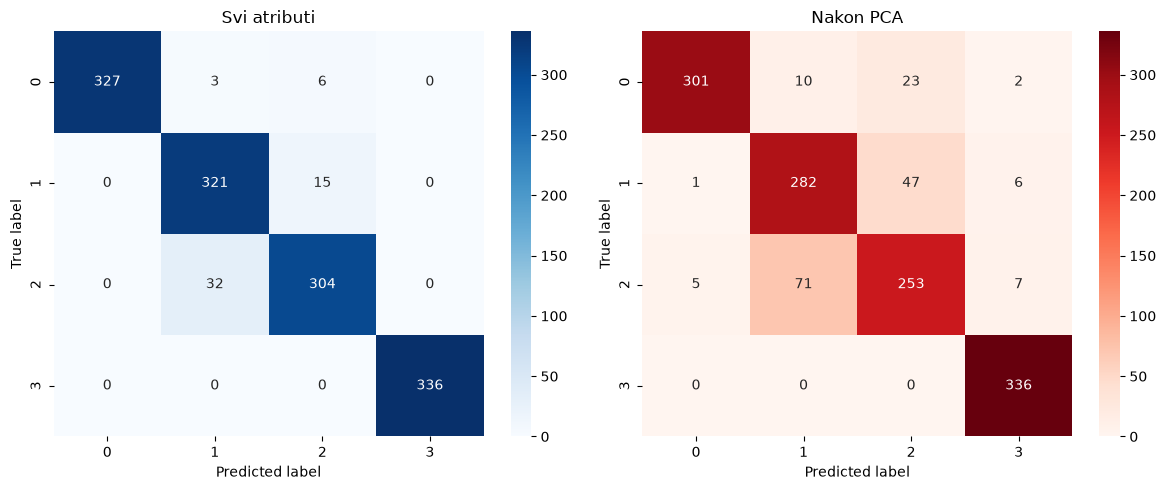

In [31]:
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.heatmap(matrica_konfuzije_rf_all,annot=True,fmt="d",cmap="Blues",ax=axes[0])

axes[0].set_title("Svi atributi")
axes[0].set_xlabel("Predicted label")
axes[0].set_ylabel("True label")

sns.heatmap(matrica_konfuzije_rf_pca,annot=True,fmt="d",cmap="Reds",ax=axes[1])

axes[1].set_title("Nakon PCA")
axes[1].set_xlabel("Predicted label")
axes[1].set_ylabel("True label")

plt.tight_layout()
plt.show()

### AdaBoost algoritam

In [32]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

base_tree = DecisionTreeClassifier(max_depth=1,random_state=42)

ada_model_all = AdaBoostClassifier(
    estimator=base_tree,
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)

# treniranje modela
ada_model_all.fit(X_train_all, y_train)

# predikcija
y_pred_ada = ada_model_all.predict(X_test_all)

# evaluacija
accuracy_all = accuracy_score(y_test, y_pred_ada)
precision_all = precision_score(y_test, y_pred_ada, average='weighted')
recall_all = recall_score(y_test, y_pred_ada, average='weighted')
f1_all = f1_score(y_test, y_pred_ada, average='weighted')

print(f"Accuracy : {accuracy_all:.4f}")
print(f"Precision: {precision_all:.4f}")
print(f"Recall   : {recall_all:.4f}")
print(f"F1-score : {f1_all:.4f}")

results_clf.append({
    "Model": "AdaBoost",
    "Skup prediktora": "Svi atributi",
    "Accuracy": accuracy_all,
    "Precision": precision_all,
    "Recall": recall_all,
    "F1-score": f1_all
})

Accuracy : 0.7440
Precision: 0.7608
Recall   : 0.7440
F1-score : 0.7502


In [33]:
ada_model_pca = AdaBoostClassifier(
    estimator=base_tree,
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)

ada_model_pca.fit(X_train_pca, y_train)

y_pred_ada_pca = ada_model_pca.predict(X_test_pca)

accuracy_pca = accuracy_score(y_test, y_pred_ada_pca)
precision_pca = precision_score(y_test, y_pred_ada_pca, average='weighted')
recall_pca = recall_score(y_test, y_pred_ada_pca, average='weighted')
f1_pca = f1_score(y_test, y_pred_ada_pca, average='weighted')

print(f"Accuracy : {accuracy_pca:.4f}")
print(f"Precision: {precision_pca:.4f}")
print(f"Recall   : {recall_pca:.4f}")
print(f"F1-score : {f1_pca:.4f}")

results_clf.append({
    "Model": "AdaBoost",
    "Skup prediktora": "Posle PCA",
    "Accuracy": accuracy_pca,
    "Precision": precision_pca,
    "Recall": recall_pca,
    "F1-score": f1_pca
})

Accuracy : 0.7135
Precision: 0.7167
Recall   : 0.7135
F1-score : 0.7139


Vidimo da su ovde performanse najniže od svih pet algoritama - za skup sa svim atributima Accuracy je 0.74, a za PCA skup 0.71, dok su i ostale metrike u istom rangu. Ovo je i najmanji pad performansi usled PCA redukcije, ali to je pre svega zato što je AdaBoost slabiji na oba skupa, a ne zato što manje gubi informaciju.

Razlog slabijih performansi leži u samoj prirodi algoritma: AdaBoost ovde koristi "panj" (decision stump, max_depth=1) kao slabi klasifikator - svako stablo pravi odluku na osnovu samo jednog atributa i jednog praga. Iako ansambl od 100 ovakvih panjeva sekvencijalno ispravlja greške prethodnih (fokusirajući se sve više na pogrešno klasifikovane uzorke), suma jednostavnih linearnih granica po jednoj promenljivoj teško može da uhvati složene, nelinearne i međusobno zavisne odnose između fizioloških karakteristika i tipa aktivnosti. Zato AdaBoost sa plitkim stablima zaostaje kako za Random Forest-om (koji koristi mnogo dublja, ekspresivnija stabla, max_depth=10), tako i za SVM-om sa Gausovim jezgrom. Zato ćemo implementirati i XGBoost algoritam, koji takođe koristi boosting, ali sa dubljim stablima i regularizacijom, pa se očekuje bolji rezultat.

### XGBoost algoritam

In [35]:
from xgboost import XGBClassifier

#xgboost zahteva da target bude u formatu 0,1,2,...,n-1 za klasifikaciju sa n klasama, pa moramo modifikovati y_train i y_test
y_train_xgb = y_train - 1
y_test_xgb = y_test - 1

xgb_model_all = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softmax",
    num_class=4,
    eval_metric="mlogloss",
    random_state=42
)

xgb_model_all.fit(X_train_all, y_train_xgb)

y_pred_xgb = xgb_model_all.predict(X_test_all)

accuracy = accuracy_score(y_test_xgb, y_pred_xgb)
precision = precision_score(y_test_xgb, y_pred_xgb, average="weighted")
recall = recall_score(y_test_xgb, y_pred_xgb, average="weighted")
f1 = f1_score(y_test_xgb, y_pred_xgb, average="weighted")

print("XGBoost rezultati:")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")


matrica_konfuzija_xgb_all = confusion_matrix(y_test_xgb, y_pred_xgb)

results_clf.append({
    "Model": "XGBoost",
    "Skup prediktora": "Svi atributi",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1
})

XGBoost rezultati:
Accuracy : 0.9888
Precision: 0.9889
Recall   : 0.9888
F1-score : 0.9888


In [36]:
y_train_xgb = y_train - 1
y_test_xgb = y_test - 1

xgb_model_pca = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softmax",
    num_class=4,
    eval_metric="mlogloss",
    random_state=42
)

xgb_model_pca.fit(X_train_pca, y_train_xgb)

y_pred_xgb = xgb_model_pca.predict(X_test_pca)

accuracy = accuracy_score(y_test_xgb, y_pred_xgb)
precision = precision_score(y_test_xgb, y_pred_xgb, average="weighted")
recall = recall_score(y_test_xgb, y_pred_xgb, average="weighted")
f1 = f1_score(y_test_xgb, y_pred_xgb, average="weighted")

print("XGBoost rezultati:")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")


matrica_konfuzija_xgb_pca = confusion_matrix(y_test_xgb, y_pred_xgb)

results_clf.append({
    "Model": "XGBoost",
    "Skup prediktora": "Posle PCA",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1
})

XGBoost rezultati:
Accuracy : 0.8839
Precision: 0.8853
Recall   : 0.8839
F1-score : 0.8843


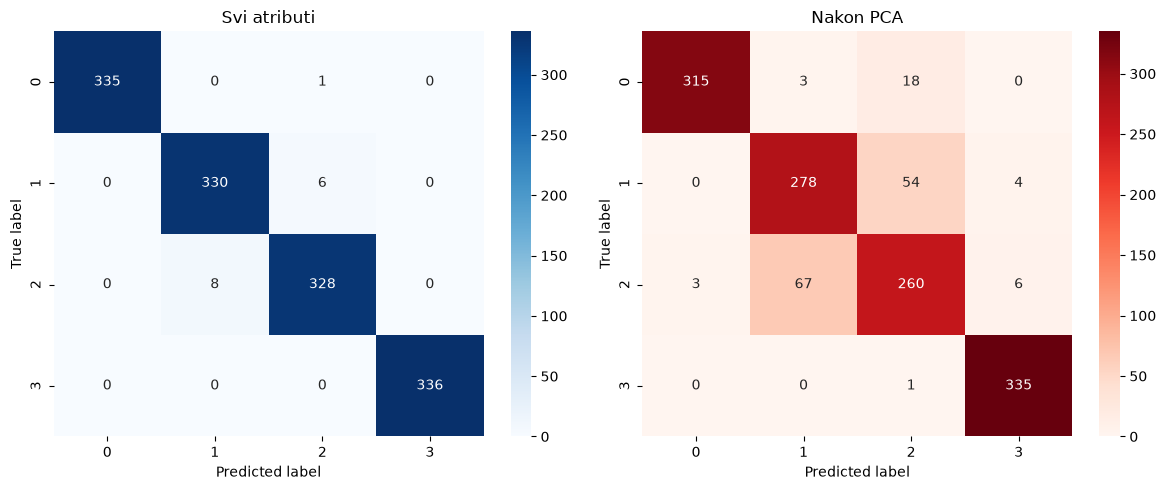

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.heatmap(matrica_konfuzija_xgb_all,annot=True,fmt="d",cmap="Blues",ax=axes[0])

axes[0].set_title("Svi atributi")
axes[0].set_xlabel("Predicted label")
axes[0].set_ylabel("True label")

sns.heatmap(matrica_konfuzija_xgb_pca,annot=True,fmt="d",cmap="Reds",ax=axes[1])

axes[1].set_title("Nakon PCA")
axes[1].set_xlabel("Predicted label")
axes[1].set_ylabel("True label")

plt.tight_layout()
plt.show()

Rezultati pokazuju da je XGBoost ostvario najveće performanse od svih pet algoritama na skupu sa svim prediktorima - Accuracy od 0.99, uz precision/recall/F1 na istom nivou. Nakon primene PCA uočava se očekivani pad performansi (na 0.88), ali model i dalje zadržava relativno visok nivo tačnosti (bolji od Random Forest-a), što ukazuje da je najveći deo informacija relevantnih za klasifikaciju sačuvan i nakon redukcije dimenzionalnosti, a da regularizacija i sekvencijalno ispravljanje grešaka (gradient boosting) daju XGBoost-u prednost u odnosu na "obično" nasumično usrednjavanje stabala kod Random Forest-a.

Zbog visoke tačnosti, koja može da zavarava usled preprilagođavanja, proverićemo kros-validacijom da li došlo da preprilagođavanja.


In [38]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf_shuffled = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_shuffled = cross_val_score(xgb_model_all, X_standardized, y-1, cv=skf_shuffled, scoring="accuracy")

print("Izmešan CV:", cv_shuffled)
print(f"Prosek: {cv_shuffled.mean():.4f}")

Izmešan CV: [0.984375   0.98883929 0.98995536 0.97991071 0.97879464]
Prosek: 0.9844


 Korišćena je unakrsnu validaciju sa nasumičnim mešanjem podataka (`shuffle=True`), za razliku od podrazumevanog `StratifiedKFold`-a bez mešanja.
Bez mešanja, uzorci istog ispitanika ostaju skoncentrisani unutar pojedinačnih foldova, čime se dobija znatno niža procena performansi (oko 0.75). Nasumičnim mešanjem pre deljenja na foldove obezbeđuje se da svaki fold sadrži reprezentativan, nasumičan uzorak iz celog skupa podataka, čime se dobija procena uporediva sa onom koju daje originalni `train_test_split`.

Dobijeni rezultati su konzistentni kroz sve foldove i vrlo bliski tačnosti dobijenoj na originalnom test skupu, uz izuzetno malo odstupanje. Ovo potvrđuje da se model ne preprilagođava na konkretnoj, jednokratnoj trening/test podeli - visoka tačnost je stabilna nezavisno od toga koji konkretni uzorci se nađu u trening, a koji u test skupu. 

Za razliku od AdaBoost-a, koji koristi vrlo plitke panjeve (max_depth=1) i gubi na ekspresivnosti, XGBoost koristi nešto dublja stabla (max_depth=4) u kombinaciji sa regularizacijom (subsample i colsample_bytree < 1, što unosi nasumičnost i sprečava preprilagođavanja), pa uspeva da uhvati složenije nelinearne odnose bez prekomernog prilagođavanja skupu za treniranje. Ovo XGBoost čini ubedljivo najboljim modelom u ovoj analizi, kako po tačnosti tako i po robusnosti na redukciju dimenzionalnosti.

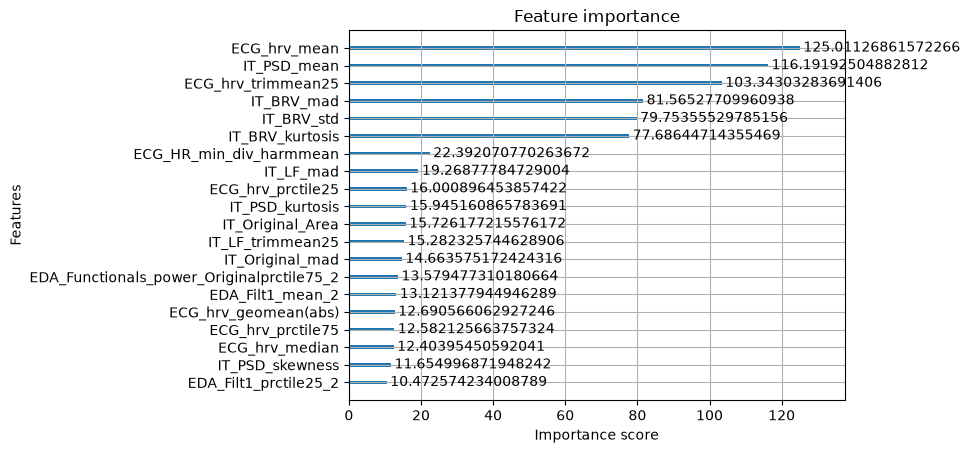

In [39]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

#grafik značajnosti prediktora
booster = xgb_model_all.get_booster()
booster.feature_names = list(X.columns)
plot_importance(
    booster,
    importance_type="gain",
    max_num_features=20
)
plt.show()

Grafik pokazuje da XGBoost ne koristi sve atribute podjednako, već najveći doprinos klasifikaciji imaju određene karakteristike, dok je uticaj ostalih znatno manji. To ukazuje da model najveći deo odluka zasniva na ograničenom broju najinformativnijih karakteristika, koje prema kriterijumu gain ostvaruju najveće smanjenje greške prilikom izgradnje stabala odlučivanja.

Ovo je u skladu i sa ranijim zapažanjem da je Pirsonov filter odbacio 430 od 533 atributa zbog visoke međusobne korelisanosti - jasno je da veliki deo od preostalih 103 "nezavisnih" atributa (a još više onih odbačenih zbog korelacije sa njima) zapravo nosi malu dodatnu informativnu vrednost za XGBoost, dok je informacija koncentrisana u relativno malom broju karakteristika (najčešće vezanih za varijabilnost srčanog ritma i amplitudu EDA odgovora, koje su fiziološki najosetljivije na promenu tipa aktivnosti). Ovo dodatno objašnjava zašto PCA više šteti modelima zasnovanim na stablima nego linearnim/margin modelima.

### Sumiran pregled performansi algoritama klasifikacije

Sve rezultate klasifikacije ćemo sažmeti na jednom mestu i uporediti modele međusobno.

               Model Skup prediktora  Accuracy  Precision   Recall  F1-score
             XGBoost       Posle PCA  0.883929   0.885303 0.883929  0.884324
       Random Forest       Posle PCA  0.872024   0.874466 0.872024  0.872275
                 SVM       Posle PCA  0.831101   0.837197 0.831101  0.832537
Logisticka regresija       Posle PCA  0.813244   0.815382 0.813244  0.814240
            AdaBoost       Posle PCA  0.713542   0.716747 0.713542  0.713933
             XGBoost    Svi atributi  0.988839   0.988859 0.988839  0.988846
       Random Forest    Svi atributi  0.958333   0.959268 0.958333  0.958497
Logisticka regresija    Svi atributi  0.872768   0.872929 0.872768  0.872755
                 SVM    Svi atributi  0.843006   0.847089 0.843006  0.843709
            AdaBoost    Svi atributi  0.744048   0.760782 0.744048  0.750189


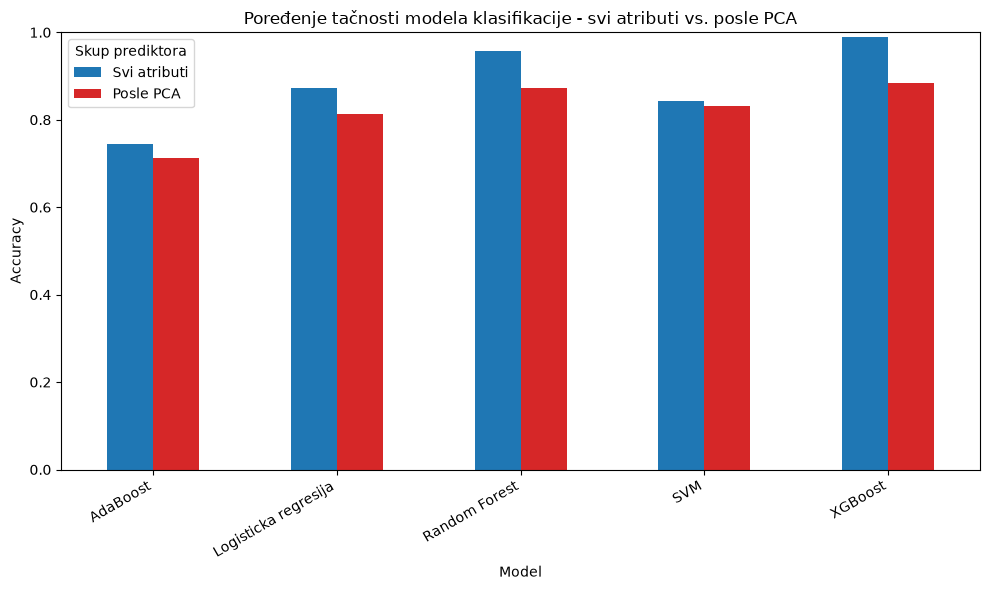

In [41]:
df_results_clf = pd.DataFrame(results_clf)
df_results_clf_sorted = df_results_clf.sort_values(by=["Skup prediktora", "Accuracy"], ascending=[True, False])
df_results_clf = df_results_clf.drop_duplicates(subset=["Model", "Skup prediktora"], keep="last")
print(df_results_clf_sorted.to_string(index=False))

pivot_acc = df_results_clf.pivot(index="Model", columns="Skup prediktora", values="Accuracy")
pivot_acc = pivot_acc[["Svi atributi", "Posle PCA"]]

ax = pivot_acc.plot(kind="bar", figsize=(10,6), color=["#1f77b4", "#d62728"])
ax.set_ylabel("Accuracy")
ax.set_title("Poređenje tačnosti modela klasifikacije - svi atributi vs. posle PCA")
ax.set_ylim(0, 1)
ax.legend(title="Skup prediktora")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

#### Sumarni pregled potvrđuje nekoliko zaključaka iz prethodnih pojedinačnih analiza:

- **XGBoost** - ubedljivo najbolji model nad oba skupa prediktora, zahvaljujući kombinaciji dovoljno dubokih stabala i regularizacije kroz boosting.
- **Random Forest** - drugi najbolji nad svim atributima, ali beleži jedan od najvećih padova nakon PCA redukcije - ansambl metode zasnovane na stablima najviše profitiraju od originalnih, interpretabilnih atributa.
- **Logistička regresija** i **SVM** su stabilniji na redukciju dimenzionalnosti (manji relativni pad), jer linearni/margin modeli ne zavise od originalne informacije pojedinačnih atributa na isti način kao stabla odlučivanja, već kombinuju informaciju iz svih prediktora istovremeno kroz težinske koeficijente.
- **AdaBoost** je najslabiji model na oba skupa - njegovi plitki "panjevi" nisu dovoljno ekspresivni za ovaj problem, za razliku od dubljih stabala kod Random Forest-a i XGBoost-a.

Generalno, PCA redukcija dosledno smanjuje performanse svih modela (jer se odbacuje 5% varijanse koja očigledno nosi diskriminativnu informaciju, naročito za razgraničenje mentalne i emocionalne aktivnosti), ali je taj efekat znatno izraženiji kod modela zasnovanih na stablima nego kod linearnih/margin modela.

## Klasterovanje

Za klasterovanje target promenljive koristićemo pet algoritama: KMeans++, Hierarchical (Agglomerative) clustering, DBSCAN, HDBSCAN i GMM. KMeans++ i Hierarchical clustering zahtevaju unapred zadati broj klastera - kako target promenljiva ima 4 različite grupe, testiraćemo vrednosti u okolini tog broja, ali i šire, da bismo proverili da li podaci "prirodno" formiraju baš 4 klastera ili neki drugi broj daje bolju unutrašnju strukturu.

Svaki algoritam ćemo pustiti u for petlji nad više različitih kombinacija parametara, i za svaku kombinaciju izračunati Silhouette, Calinski-Harabasz i Davies-Bouldin indeks. Na taj način dobijamo potpuniju sliku o tome koliko je izbor hiperparametara uticao na kvalitet klasterovanja, umesto da se oslanjamo na rezultat jedne, unapred izabrane konfiguracije.

Najpre ćemo raditi nad celim (standardizovanim) skupom podataka, a onda nad PCA skupom i uporediti rezultate.

In [42]:
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
import hdbscan
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

def evaluate_clustering(X, labels, sample_size=500, random_state=42):
    """Racuna broj klastera (bez suma -1) i tri evaluacione metrike za dati skup oznaka klastera."""
    unique_labels = set(labels)
    n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)

    if len(unique_labels) > 1:
        try:
            sil = silhouette_score(X, labels, sample_size=min(sample_size, len(labels)), random_state=random_state)
        except ValueError:
            # nasumicni uzorak za silhouette nije obuhvatio sve klastere
            # (cest slucaj kod jako neuravnotezenih klastera, npr. average/complete linkage)
            sil = None
        ch = calinski_harabasz_score(X, labels)
        db = davies_bouldin_score(X, labels)
    else:
        sil, ch, db = None, None, None

    return n_clusters, sil, ch, db

def run_clustering_grid(X, dataset_name):
    """Za dati skup prediktora X, prolazi kroz vise kombinacija hiperparametara za svaki od
    pet algoritama klasterovanja, cuva evaluacione metrike i oznake klastera za svaku konfiguraciju."""
    results = []
    all_labels = {}

    #KMeans++ - variramo k
    for k in [2, 3, 4, 5, 6]:
        model = KMeans(n_clusters=k, init="k-means++", random_state=42, n_init=10)
        labels = model.fit_predict(X)
        cfg_name = f"kmeans_pp (k={k})"
        n_clusters, sil, ch, db = evaluate_clustering(X, labels)
        results.append({"Dataset": dataset_name, "Family": "KMeans++", "Config": cfg_name,
                         "Clusters": n_clusters, "Silhouette": sil,
                         "Calinski-Harabasz": ch, "Davies-Bouldin": db})
        all_labels[cfg_name] = labels

    #Hierarchical - variramo k i linkage
    for k in [3, 4, 5]:
        for linkage in ["ward", "average", "complete"]:
            model = AgglomerativeClustering(n_clusters=k, linkage=linkage)
            labels = model.fit_predict(X)
            cfg_name = f"hierarchical (k={k}, linkage={linkage})"
            n_clusters, sil, ch, db = evaluate_clustering(X, labels)
            results.append({"Dataset": dataset_name, "Family": "Hierarchical", "Config": cfg_name,
                             "Clusters": n_clusters, "Silhouette": sil,
                             "Calinski-Harabasz": ch, "Davies-Bouldin": db})
            all_labels[cfg_name] = labels

    #DBSCAN - variramo eps i min_samples 
    for eps in [0.05, 0.1, 0.2, 0.3]:
        for min_samples in [10, 30, 50]:
            model = DBSCAN(eps=eps, min_samples=min_samples)
            labels = model.fit_predict(X)
            cfg_name = f"dbscan (eps={eps}, min_samples={min_samples})"
            n_clusters, sil, ch, db = evaluate_clustering(X, labels)
            results.append({"Dataset": dataset_name, "Family": "DBSCAN", "Config": cfg_name,
                             "Clusters": n_clusters, "Silhouette": sil,
                             "Calinski-Harabasz": ch, "Davies-Bouldin": db})
            all_labels[cfg_name] = labels

    for mcs in [30, 50, 100, 150]:
        model = hdbscan.HDBSCAN(min_cluster_size=mcs)
        labels = model.fit_predict(X)
        cfg_name = f"hdbscan (min_cluster_size={mcs})"
        n_clusters, sil, ch, db = evaluate_clustering(X, labels)
        results.append({"Dataset": dataset_name, "Family": "HDBSCAN", "Config": cfg_name,
                         "Clusters": n_clusters, "Silhouette": sil,
                         "Calinski-Harabasz": ch, "Davies-Bouldin": db})
        all_labels[cfg_name] = labels

    #GMM (Gaussian Mixture Model) - variramo broj komponenti i tip kovarijanse
    for n_comp in [3, 4, 5, 6]:
        for cov_type in ["full", "tied", "diag"]:
            model = GaussianMixture(n_components=n_comp, covariance_type=cov_type, random_state=42)
            labels = model.fit_predict(X)
            cfg_name = f"gmm (n_components={n_comp}, covariance={cov_type})"
            n_clusters, sil, ch, db = evaluate_clustering(X, labels)
            results.append({"Dataset": dataset_name, "Family": "GMM", "Config": cfg_name,
                             "Clusters": n_clusters, "Silhouette": sil,
                             "Calinski-Harabasz": ch, "Davies-Bouldin": db})
            all_labels[cfg_name] = labels

    return pd.DataFrame(results), all_labels


def best_config_per_family(results_df, all_labels):
    """Za svaku porodicu algoritama bira konfiguraciju sa najvecim Silhouette indeksom."""
    best = {}
    for family in results_df["Family"].unique():
        subset = results_df[(results_df["Family"] == family) & (results_df["Silhouette"].notna())]
        if len(subset) == 0:
            continue
        best_row = subset.loc[subset["Silhouette"].idxmax()]
        best[family] = (best_row["Config"], all_labels[best_row["Config"]])
    return best

In [43]:
results_all_df, all_labels_all = run_clustering_grid(X_standardized, "Svi atributi")

In [44]:
results_all_df.sort_values("Silhouette", ascending=False).head(20)

,Dataset,Family,Config,Clusters,Silhouette,Calinski-Harabasz,Davies-Bouldin
0,Svi atributi,KMeans++,kmeans_pp (k=2),2,0.320300,663.816230,2.151960
31,Svi atributi,GMM,"gmm (n_components=3, covariance=tied)",3,0.318125,582.017569,1.565335
1,Svi atributi,KMeans++,kmeans_pp (k=3),3,0.301493,610.219532,1.751212
34,Svi atributi,GMM,"gmm (n_components=4, covariance=tied)",4,0.300701,581.436256,1.476428
2,Svi atributi,KMeans++,kmeans_pp (k=4),4,0.298563,633.276740,1.397482
3,Svi atributi,KMeans++,kmeans_pp (k=5),5,0.297363,640.421340,1.161352
30,Svi atributi,GMM,"gmm (n_components=3, covariance=full)",3,0.262310,550.639841,1.627438
8,Svi atributi,Hierarchical,"hierarchical (k=4, linkage=ward)",4,0.260801,563.169173,1.628007
11,Svi atributi,Hierarchical,"hierarchical (k=5, linkage=ward)",5,0.260801,579.470863,1.372034
37,Svi atributi,GMM,"gmm (n_components=5, covariance=tied)",5,0.250366,578.674031,1.630240


Testiranjem više kombinacija hiperparametara po algoritmu dobijamo mnogo potpuniju sliku od jedne fiksne konfiguracije.

Korišćene metrike evaluacije su:

- **Silhouette koeficijent** — veće vrednosti su bolje (maksimum 1), mеri koliko su tačke slične sopstvenom klasteru u odnosu na susedne klastere.
- **Calinski-Harabasz indeks (CH)** — veće vrednosti su bolje, odnos odstupanja između klastera i unutar klastera.
- **Davies-Bouldin indeks (DB)** — manje vrednosti su bolje, meri prosečnu sličnost između klastera.


Vidimo da konfiguracija `kmeans_pp (k=2)` ostvaruje najveći Silhouette skor i najveći CH indeks u celoj tabeli, što ukazuje na najjasniju geometrijsku razdvojenost klastera. Međutim, DB indeks je istovremeno najgori u tabeli. Ova naizgled kontradiktorna kombinacija sugeriše da podela na samo dva klastera može biti previše gruba — model spaja podklastere koji bi mogli biti razdvojeni, što DB metrika procenjuje kao slabiju unutar-klaster koheziju u odnosu na rastojanje između klastera.



Konfiguracije `gmm (n_components=3, covariance=tied)` i `gmm (n_components=4, covariance=tied)` postižu Silhouette vrednosti od 0.3181 i 0.3007, respektivno — praktično na nivou najboljeg KMeans rezultata — dok istovremeno imaju znatno bolje DB vrednosti (1.57 i 1.48).
Uočava se jasan obrazac: GMM sa `covariance=tied` konzistentno nadmašuje `covariance=full` na istom broju komponenti. Ovo implicira da nametanje zajedničkog oblika kovarijanse svim klasterima (tied) bolje generalizuje na datom skupu podataka, dok `full` verovatno overfituje na manje ili šumovite podklastere.

Hierarchical Agglomeartive Konfiguracije sa k=4 i k=5 ostvaruju identičan Silhouette skor (oko 0.26), što ukazuje da ward linkage na ovom skupu podataka proizvodi sličnu strukturu klastera nezavisno od tačnog broja klastera u tom opsegu. DB vrednosti (1.63 i 1.37) su solidne, ali ne dominiraju nad GMM (tied) rezultatima.


Kod GMM familije uočava se jasan trend: kako se broj komponenti povećava, Silhouette skor opada, kao i CH indeks. Ovo je uobičajena posledica prekomerne segmentacije — kada se podaci veštački podele na više klastera nego što njihova prirodna struktura podržava, dolazi do razvodnjavanja kompaktnosti i separacije.

#### Zaključak

Nijedna metrika samostalno ne daje jednoznačnog "pobednika" jer se rezultati KMeans (k=2) i GMM (tied kovarijansa) razlikuju u zavisnosti od kriterijuma:

- Za **maksimalnu geometrijsku separaciju** (bez obzira na broj klastera) — najbolji izbor je **KMeans++ (k=2)**.
- Za **balansiran rezultat** koji istovremeno postiže dobru separaciju i nisku unutar-klaster disperziju — **GMM (n_components=3, covariance=tied)** predstavlja optimalan kompromis: drugo mesto po Silhouette i CH.

DBSCAN se ni ne ubraja u 20 najboljih konfiguracija, dok HDBSCAN zauzima dva poslednja mesta, sa vrlo slabim performansama.
Density based algoritmi nisu uspeli da izdvoje jasne klastere na datom skupu podataka, za razliku od centroid-based (KMeans++) i probabilističkih (GMM) metoda. Ovo sugeriše da podaci ne sadrže regione visoke gustine odvojene regionima niske gustine, koji su preduslov za density-based pristup, već imaju kontinuiranu, globularnu/eliptičnu strukturu bez oštrih granica između grupa. 

Vizuelizacija klasterizacije koristeći UMAP algoritam:

c:\Users\gala.posedi\Desktop\fakultet\IP2\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


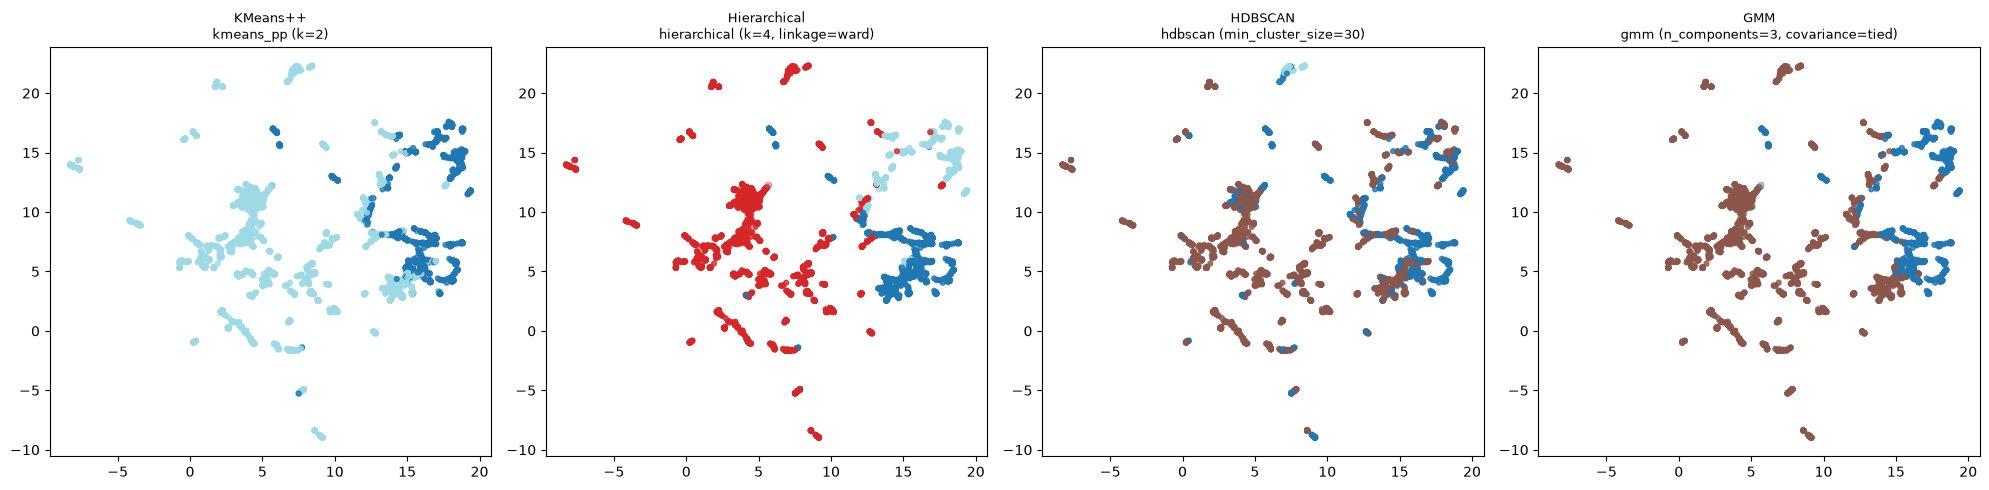

In [45]:
import umap
from umap import UMAP

umap_model = UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
X_umap = umap_model.fit_transform(X_standardized)

best_all = best_config_per_family(results_all_df, all_labels_all)

fig, axes = plt.subplots(1, len(best_all), figsize=(5*len(best_all), 5))
for ax, (family, (cfg_name, labels)) in zip(axes, best_all.items()):
    ax.scatter(X_umap[:, 0], X_umap[:, 1], c=labels, cmap="tab20", s=12, alpha=0.8)
    ax.set_title(f"{family}\n{cfg_name}", fontsize=9)

plt.tight_layout()
plt.show()

Na UMAP vizuelizaciji prikazana je najbolja konfiguracija (po Silhouette indeksu) za svaku od pet algoritama, nad kompletnim skupom atributa. Ovo omogućava direktno vizuelno poređenje - da li centroidne metode zaista formiraju kompaktne, dobro razdvojene grupe, dok gustinski zasnovane metode formiraju nepravilne, izmešane ili premale klastere.

Sada ćemo odraditi istu klasterizaciju samo nad PCA izabranim prediktorima.

In [ ]:
results_pca_df, all_labels_pca = run_clustering_grid(X_pca, "Posle PCA")
results_pca_df.sort_values("Silhouette", ascending=False).head(20)

c:\Users\gala.posedi\Desktop\fakultet\IP2\.venv\Lib\site-packages\sklearn\mixture\_base.py:293: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


,Dataset,Family,Config,Clusters,Silhouette,Calinski-Harabasz,Davies-Bouldin
31,Posle PCA,GMM,"gmm (n_components=3, covariance=tied)",3,0.342784,618.655246,1.507958
34,Posle PCA,GMM,"gmm (n_components=4, covariance=tied)",4,0.342304,599.846849,1.212683
0,Posle PCA,KMeans++,kmeans_pp (k=2),2,0.332968,703.304054,2.073728
1,Posle PCA,KMeans++,kmeans_pp (k=3),3,0.318031,650.778141,1.692668
2,Posle PCA,KMeans++,kmeans_pp (k=4),4,0.318031,680.505376,1.344887
37,Posle PCA,GMM,"gmm (n_components=5, covariance=tied)",5,0.317298,606.190970,1.206356
3,Posle PCA,KMeans++,kmeans_pp (k=5),5,0.313663,693.703075,1.133519
8,Posle PCA,Hierarchical,"hierarchical (k=4, linkage=ward)",4,0.280562,594.264311,1.558878
11,Posle PCA,Hierarchical,"hierarchical (k=5, linkage=ward)",5,0.280562,617.426970,1.314836
40,Posle PCA,GMM,"gmm (n_components=6, covariance=tied)",6,0.269655,598.894401,1.317636


c:\Users\gala.posedi\Desktop\fakultet\IP2\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


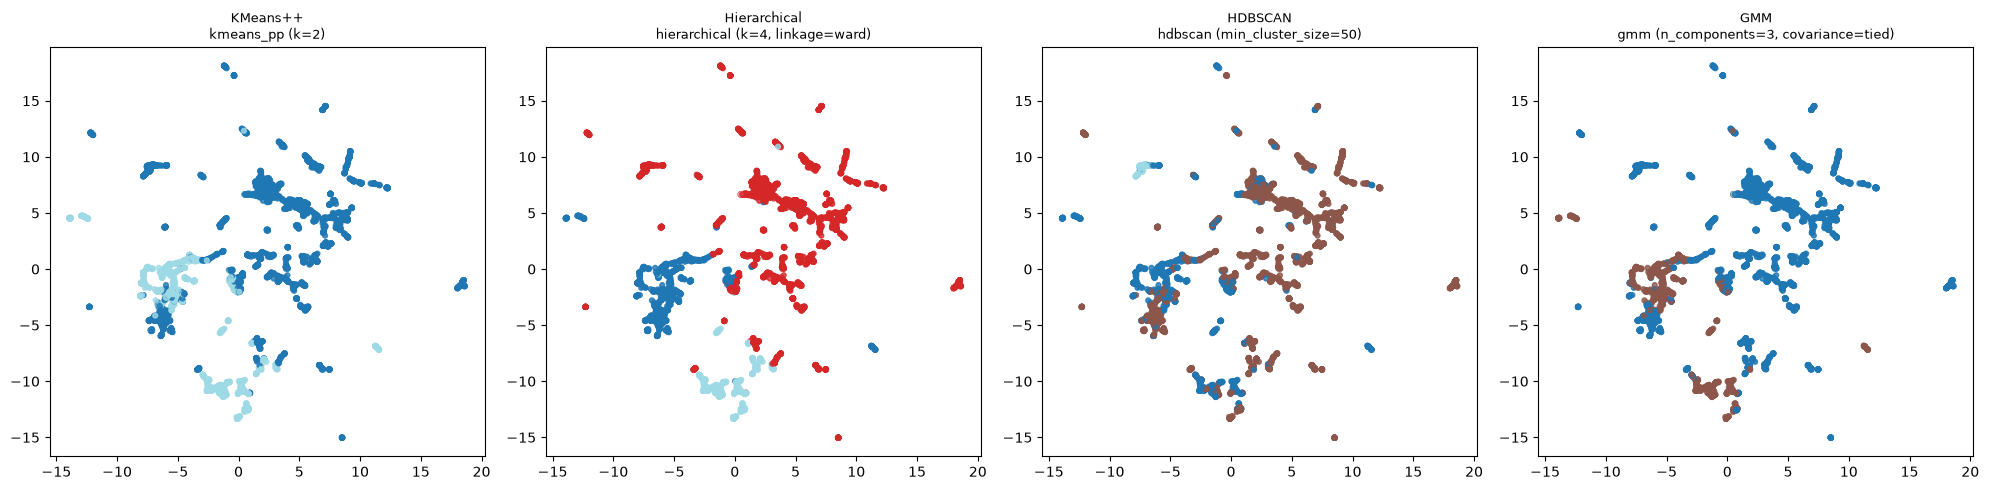

In [48]:
umap_model = UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
X_umap_pca = umap_model.fit_transform(X_pca)

best_pca = best_config_per_family(results_pca_df, all_labels_pca)

fig, axes = plt.subplots(1, len(best_pca), figsize=(5*len(best_pca), 5))
for ax, (family, (cfg_name, labels)) in zip(axes, best_pca.items()):
    ax.scatter(X_umap_pca[:, 0], X_umap_pca[:, 1], c=labels, cmap="tab20", s=12, alpha=0.8)
    ax.set_title(f"{family}\n{cfg_name}", fontsize=9)

plt.tight_layout()
plt.show()

**Poređenje klasterovanja nad svim atributima i nad PCA skupom:**

Uporedimo najbolji Silhouette indeks po porodici algoritma na oba skupa (`results_all_df` vs `results_pca_df`). Na osnovu prethodnog (jednoparametarskog) eksperimenta iz originalne verzije analize, klasterovanje nad PCA skupom davalo je nešto viši Silhouette indeks za KMeans++  i Hierarchical clustering, kao i za HDBSCAN. Ovo je suprotno od onoga što smo videli kod klasifikacije - dok su klasifikacioni modeli (naročito stabla) gubili na tačnosti nakon PCA, klasterovanje se ovde poboljšava.

Razlog za ovo je što klasterovanje ne koristi informaciju o ciljnoj promenljivoj, već se oslanja isključivo na geometriju rastojanja između tačaka u prostoru prediktora - a PCA upravo optimizuje taj prostor tako da su najvažniji pravci varijabilnosti istaknuti, dok se šum i redundantne, međusobno visoko korelisane dimenzije uklanjaju. Manje, "gušće" PCA reprezentacije olakšavaju centroidnim algoritmima da pronađu kompaktnije i bolje razdvojene klastere, dok kod klasifikacije PCA može odbaciti baš one dimenzije koje su ključne za razgraničenje određenih (fiziološki sličnih) klasa.

## Pravila pridruživanja

Implementiraćemo dve metode - Apriori i FP-Growth algoritam - nad prediktorima dobijenim **Pirsonovim filterom** (103 atributa).

Ovo je namerna izmena u odnosu na klasifikaciju i klasterovanje: PCA komponente (PC1, PC2, ...) su apstraktne linearne kombinacije originalnih atributa i nemaju direktno fiziološko značenje, pa bi pravilo tipa `PC5_low -> Activity_4` bilo teško protumačiti u kontekstu stvarnih fizioloških signala. Nasuprot tome, Pirsonov filter samo uklanja redundantne atribute i zadržava originalna imena preostalih (npr. `ECG_RR_window_mean`, `EDA_amp_scr`), pa pravila pridruživanja dobijena nad ovim skupom mogu direktno da se protumače.

Nakon generisanja pravila pridruživanja izvršićemo i filtriranje na osnovu vrednosti support, confidence i lift, kako bismo izdvojili samo pravila koja se javljaju dovoljno često, imaju visoku pouzdanost i predstavljaju statistički značajnu povezanost između stavki:

- **Support** (podrška) - udeo transakcija (uzoraka) u kojima se javljaju i antecedent i konsekvent zajedno.
- **Confidence** (pouzdanost) - uslovna verovatnoća da se konsekvent javi ako se antecedent već javio.
- **Lift** - meri koliko je jače pravilo od onoga što bi se očekivalo pri nezavisnosti antecedenta i konsekventa.

Ograničićemo support >= 0.10 (javljaju se u bar 10% uzoraka), confidence >= 0.70 (u bar 70% slučajeva kada se javi antecedent, javlja se i konsekvent) i lift >= 1.50 (asocijacija je bar 50% jača od slučajne), jer se na taj način izdvaja samo pravila koja se javljaju dovoljno često, imaju visoku pouzdanost i predstavljaju statistički značajnu povezanost između stavki.

In [63]:
from mlxtend.frequent_patterns import apriori, association_rules

#Apriori algoritam 
X_top = X_pearson.reset_index(drop=True)

#diskretizacija numeričkih promenljivih
def discretize_column(col):
    try:
        bins = pd.qcut(col, q=3, labels=False, duplicates="drop")
        return bins.map({0: "low", 1: "medium", 2: "high"})
    except:
        return "constant"

X_disc = X_top.apply(discretize_column)

X_disc["Activity"] = "Activity_" + y.reset_index(drop=True).astype(str)

transactions = pd.get_dummies(X_disc.astype(str))

frequent_itemsets = apriori(transactions,min_support=0.01,use_colnames=True,max_len=2)

rules = association_rules(frequent_itemsets,metric="confidence",min_threshold=0.70)
target_rules = rules[rules['consequents'].apply(lambda x: any(str(item).startswith('Activity_') for item in x))]

rules_f = rules[(rules["support"] >= 0.10) &(rules["confidence"] >= 0.70) &(rules["lift"] >= 1.50)
                ].sort_values(by="confidence", ascending=False)

print("Broj pravila koji sadrže Activity za konsekventa:", len(target_rules))
print("Filtrirana pravila:", len(rules_f))

target_rules[["antecedents", "consequents", "support", "confidence", "lift"]]


Broj pravila koji sadrže Activity za konsekventa: 5
Filtrirana pravila: 265


c:\Users\gala.posedi\Desktop\fakultet\IP2\.venv\Lib\site-packages\mlxtend\frequent_patterns\association_rules.py:184: RuntimeWarning: invalid value encountered in divide
  cert_metric = np.where(certainty_denom == 0, 0, certainty_num / certainty_denom)


,antecedents,consequents,support,confidence,lift
2021,(IT_Original_std_high),(Activity_Activity_4),0.245312,0.735609,2.942436
2420,(IT_BRV_skewness_high),(Activity_Activity_1),0.021652,0.979798,3.919192
2928,(IT_VLF_skewness_medium),(Activity_Activity_1),0.028348,0.984496,3.937984
3357,(IT_MF_kurtosis_medium),(Activity_Activity_1),0.010937,0.980000,3.920000
3458,(IT_p_Total_skewness_medium),(Activity_Activity_1),0.017634,0.975309,3.901235


In [66]:
rules_f[["antecedents", "consequents", "support", "confidence", "lift"]].head(20)

,antecedents,consequents,support,confidence,lift
2639,(IT_PSD_mean_medium),(IT_VLF_std_medium),0.327902,1.000000,3.049694
2398,(IT_PSD_mean_medium),(IT_BRV_std_medium),0.327902,1.000000,3.049694
2638,(IT_VLF_std_medium),(IT_PSD_mean_medium),0.327902,1.000000,3.049694
2400,(IT_BRV_std_medium),(IT_VLF_std_medium),0.327902,1.000000,3.049694
2401,(IT_VLF_std_medium),(IT_BRV_std_medium),0.327902,1.000000,3.049694
2616,(IT_PSD_mean_high),(IT_VLF_std_high),0.328125,1.000000,3.047619
2617,(IT_VLF_std_high),(IT_PSD_mean_high),0.328125,1.000000,3.047619
2629,(IT_PSD_mean_low),(IT_VLF_std_low),0.343973,1.000000,2.907203
2630,(IT_VLF_std_low),(IT_PSD_mean_low),0.343973,1.000000,2.907203
2397,(IT_BRV_std_medium),(IT_PSD_mean_medium),0.327902,1.000000,3.049694


Nakon filtriranja pravila asocijacije na ona koja u konsekventu sadrže klasu aktivnosti, izdvojeno je pet najrelevantnijih pravila. Pravilo **(IT_Original_std_high) → (Activity_Activity_4)** ima najveći support (0.245), uz confidence od 0.736 i lift 2.94. Atribut **IT_Original_std_high** označava visoku standardnu devijaciju originalnog signala torakalne električne bioimpedance (IT), odnosno izraženu varijabilnost signala. Takav obrazac ukazuje da se tokom aktivnosti *Activity_4* beleže veće oscilacije u respiratornom signalu, što je očekivano za fizički intenzivnije aktivnosti kod kojih dolazi do promena u dubini i ritmu disanja. Najveći support ovog pravila pokazuje da je upravo povećana varijabilnost IT signala najčešće prisutna karakteristika ove klase aktivnosti.

Preostala četiri pravila povezuju atribute **skewness** i **kurtosis** signala **IT_BRV**, **IT_VLF**, **IT_MF** i **IT_p_Total** sa klasom **Activity_1**. Ovi atributi ne opisuju intenzitet signala, već oblik njegove raspodele. Skewness meri asimetriju raspodele, dok kurtosis opisuje izraženost ekstremnih vrednosti (težinu repova raspodele). Izuzetno visoke vrednosti confidence-a (0.975–0.984) i lift-a (3.90–3.94) ukazuju da se ovakvi obrasci gotovo isključivo javljaju kod aktivnosti *Activity_1*, iako imaju manji support zbog manje zastupljenosti ove klase u skupu podataka. Rezultati sugerišu da je *Activity_1* prepoznatljiva po specifičnoj strukturi i raspodeli respiratornog signala, dok je *Activity_4* prvenstveno karakterisana povećanom varijabilnošću signala, odnosno izraženijim promenama u respiratornoj aktivnosti.

In [70]:
from mlxtend.frequent_patterns import fpgrowth, association_rules

# FP-Growth algoritam
frequent_itemsets_fp = fpgrowth(transactions,min_support=0.05,use_colnames=True,max_len=2)

rules_fp = association_rules(frequent_itemsets_fp,metric="confidence",min_threshold=0.70)
target_rules_fp = rules_fp[rules_fp['consequents'].apply(lambda x: any(str(item).startswith('Activity_') for item in x))]

rules_fp_f = rules_fp[
    (rules_fp["support"] >= 0.10) &
    (rules_fp["confidence"] >= 0.70) &
    (rules_fp["lift"] >= 1.50)
].sort_values(by="lift", ascending=False)

print("FP-Growth pravila sa Activity za konsekventa:", len(target_rules_fp))
target_rules_fp[["antecedents", "consequents", "support", "confidence", "lift"]]

FP-Growth pravila sa Activity za konsekventa: 1


c:\Users\gala.posedi\Desktop\fakultet\IP2\.venv\Lib\site-packages\mlxtend\frequent_patterns\association_rules.py:184: RuntimeWarning: invalid value encountered in divide
  cert_metric = np.where(certainty_denom == 0, 0, certainty_num / certainty_denom)


,antecedents,consequents,support,confidence,lift
3075,(IT_Original_std_high),(Activity_Activity_4),0.245312,0.735609,2.942436


In [73]:
print("Filtrirana FP-Growth pravila:", len(rules_fp_f))
rules_fp_f[["antecedents", "consequents", "support", "confidence", "lift"]].head(20)

Filtrirana FP-Growth pravila: 265


,antecedents,consequents,support,confidence,lift
2430,(IT_PSD_mean_medium),(IT_VLF_std_medium),0.327902,1.000000,3.049694
2427,(IT_BRV_std_medium),(IT_PSD_mean_medium),0.327902,1.000000,3.049694
2428,(IT_PSD_mean_medium),(IT_BRV_std_medium),0.327902,1.000000,3.049694
2429,(IT_VLF_std_medium),(IT_PSD_mean_medium),0.327902,1.000000,3.049694
2415,(IT_VLF_std_medium),(IT_BRV_std_medium),0.327902,1.000000,3.049694
2414,(IT_BRV_std_medium),(IT_VLF_std_medium),0.327902,1.000000,3.049694
1123,(IT_PSD_mean_high),(IT_VLF_std_high),0.328125,1.000000,3.047619
1108,(IT_BRV_std_high),(IT_VLF_std_high),0.328125,1.000000,3.047619
1109,(IT_VLF_std_high),(IT_BRV_std_high),0.328125,1.000000,3.047619
1122,(IT_PSD_mean_high),(IT_BRV_std_high),0.328125,1.000000,3.047619


Nakon filtriranja pravila tako da konsekvent predstavlja klasu aktivnosti, izdvojeno je samo jedno pravilo koje zadovoljava zadate pragove. Pravilo IT_Original_std_high → Activity_4 (support = 0.245, confidence = 0.736, lift = 2.94) ukazuje da je povećana standardna devijacija originalnog signala torakalne električne bioimpedance karakteristična za fizičku aktivnost, što smo dobili kao rezultat i za Apriori algoritam.
Sa druge strane, posmatrajući sva generisana pravila, može se uočiti da se najveći broj njih odnosi na međusobne veze između izvedenih prediktora, posebno onih koji potiču iz istog fiziološkog signala. Takvi rezultati su očekivani, budući da ove karakteristike opisuju srodne aspekte istog signala i stoga pokazuju visoku međusobnu povezanost. Međutim, ova pravila ne pružaju dodatne informacije o zavisnosti između prediktora i ciljne promenljive, zbog čega nisu od značaja za interpretaciju klasifikacionog problema.